# **Assignment: Neural Machine Translation with Cross-Attention**

# **Task 1 — Preprocessing & Data Pipeline**

In [1]:
#Install the required Libraries
!pip install -q datasets tensorflow huggingface_hub

In [15]:
#Import Libraries
import tensorflow as tf
import re
import string
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
import os
import math

In [6]:
#Import HuggingFace Token
HF_TOKEN = os.getenv("HF_TOKEN")

#Load Dataset (First 50,000 Only)
dataset = load_dataset("OscarNav/spa-eng")

# Extract first 50,000 sentence pairs
raw_data = dataset["train"].select(range(50000))

print(raw_data[0])

README.md:   0%|          | 0.00/429 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.58M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/623k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/107067 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11897 [00:00<?, ? examples/s]

{'eng': 'When the curtain went up, the stage was dark.', 'spa': 'Al levantarse el telón, la escena estaba oscura.'}


In [10]:
# Text Cleaning Function
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    return text

# Prepare English & Spanish Sentences
english_sentences = []
spanish_sentences = []

for example in raw_data:
    en = clean_text(example["eng"])
    es = clean_text(example["spa"])

    english_sentences.append(en)
    spanish_sentences.append("[start] " + es + " [end]")

In [11]:
#Sanity Check
print(raw_data[0])
print("English:", english_sentences[0])
print("Spanish:", spanish_sentences[0])

{'eng': 'When the curtain went up, the stage was dark.', 'spa': 'Al levantarse el telón, la escena estaba oscura.'}
English: when the curtain went up the stage was dark
Spanish: [start] al levantarse el telón la escena estaba oscura [end]


In [12]:
#Train / Validation / Test Split (40k / 5k / 5k)
train_en = english_sentences[:40000]
train_es = spanish_sentences[:40000]

val_en = english_sentences[40000:45000]
val_es = spanish_sentences[40000:45000]

test_en = english_sentences[45000:]
test_es = spanish_sentences[45000:]

In [13]:
#Text Vectorization Layers(Vocabulary ≤ 15,000 & Max sequence length = 20)
VOCAB_SIZE = 15000
MAX_LEN = 20

#English Vectorizer
eng_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LEN
)

#Spanish Vectorizer
spa_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LEN
)

#Adapt Vectorizers (IMPORTANT)
eng_vectorizer.adapt(train_en)
spa_vectorizer.adapt(train_es)

#Convert Text → Integer Sequences
def vectorize_data(en, es):
    en = eng_vectorizer(en)
    es = spa_vectorizer(es)
    return en, es

#Build TensorFlow Datasets
BATCH_SIZE = 64
BUFFER_SIZE = 10000

#Training Dataset
train_ds = tf.data.Dataset.from_tensor_slices((train_en, train_es))
train_ds = train_ds.shuffle(BUFFER_SIZE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(vectorize_data)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

#Validation Dataset
val_ds = tf.data.Dataset.from_tensor_slices((val_en, val_es))
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.map(vectorize_data)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

#Test Dataset
test_ds = tf.data.Dataset.from_tensor_slices((test_en, test_es))
test_ds = test_ds.batch(1)
test_ds = test_ds.map(vectorize_data)


In [14]:
#Sanity Check
for en_batch, es_batch in train_ds.take(1):
    print("English batch shape:", en_batch.shape)
    print("Spanish batch shape:", es_batch.shape)

English batch shape: (64, 20)
Spanish batch shape: (64, 20)


# **Task 2: Multi-Head Cross-Attention layer from scratch**

In [16]:
#Scaled Dot-Product Attention (CORE LOGIC) [This is language-agnostic attention.]
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (batch, heads, seq_len_q, depth)
    K: (batch, heads, seq_len_k, depth)
    V: (batch, heads, seq_len_v, depth)
    """

    matmul_qk = tf.matmul(Q, K, transpose_b=True)

    dk = tf.cast(tf.shape(K)[-1], tf.float32)
    scaled_logits = matmul_qk / tf.math.sqrt(dk)

    if mask is not None:
        scaled_logits += (mask * -1e9)

    attention_weights = tf.nn.softmax(scaled_logits, axis=-1)
    output = tf.matmul(attention_weights, V)

    return output, attention_weights

#Custom Multi-Head Cross-Attention Layer
class MultiHeadCrossAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.depth = d_model // num_heads

        # Linear projections
        self.Wq = tf.keras.layers.Dense(d_model)
        self.Wk = tf.keras.layers.Dense(d_model)
        self.Wv = tf.keras.layers.Dense(d_model)

        # Final output projection
        self.dense = tf.keras.layers.Dense(d_model)

    #Split Heads Function
    def split_heads(self, x, batch_size):
        """
        x: (batch_size, seq_len, d_model)
        return: (batch_size, num_heads, seq_len, depth)
        """
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    #Forward Pass (IMPORTANT: Q vs K,V)
    def call(self, query, key, value, mask=None):
        """
        query: Spanish decoder output
        key:   English encoder output
        value: English encoder output
        """

        batch_size = tf.shape(query)[0]

        Q = self.Wq(query)   # (batch, spa_len, d_model)
        K = self.Wk(key)     # (batch, eng_len, d_model)
        V = self.Wv(value)   # (batch, eng_len, d_model)

        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)

        attention_output, attention_weights = scaled_dot_product_attention(
            Q, K, V, mask
        )

        # Concatenate heads
        attention_output = tf.transpose(attention_output, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(
            attention_output,
            (batch_size, -1, self.d_model)
        )

        output = self.dense(concat_attention)

        return output, attention_weights

In [17]:
#Sanity Check(cross-attention is working correctly)
# Dummy inputs
batch_size = 2
spa_len = 10
eng_len = 12
d_model = 256
num_heads = 4

cross_attention = MultiHeadCrossAttention(d_model, num_heads)

dummy_spa = tf.random.uniform((batch_size, spa_len, d_model))
dummy_eng = tf.random.uniform((batch_size, eng_len, d_model))

output, weights = cross_attention(
    query=dummy_spa,
    key=dummy_eng,
    value=dummy_eng
)

print("Output shape:", output.shape)
print("Attention weights shape:", weights.shape)

Output shape: (2, 10, 256)
Attention weights shape: (2, 4, 10, 12)


# **Task 3: Encoder–Decoder architecture**

In [20]:
#Positional Embedding Layer[Transformers need position information.]
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_model, max_len):
        super().__init__()
        self.token_emb = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_emb = tf.keras.layers.Embedding(max_len, d_model)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

#Encoder Layer(Self-attention , Feed-forward , LayerNorm)
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.self_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads
        )
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(512, activation="relu"),
            tf.keras.layers.Dense(d_model)
        ])
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.norm2 = tf.keras.layers.LayerNormalization()

    def call(self, x, mask=None):
        attn_output = self.self_attention(x, x, x, attention_mask=mask)
        x = self.norm1(x + attn_output)

        ffn_output = self.ffn(x)
        x = self.norm2(x + ffn_output)
        return x


#Encoder Model
class Encoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_model, num_heads, max_len):
        super().__init__()
        self.embedding = PositionalEmbedding(vocab_size, d_model, max_len)
        self.encoder_layer = EncoderLayer(d_model, num_heads)

    def call(self, x, mask=None):
        x = self.embedding(x)
        x = self.encoder_layer(x, mask=mask)
        return x

#Decoder Layer(Task 2: Cross-Attention is used)
class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.self_attention = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads
        )
        self.cross_attention = MultiHeadCrossAttention(d_model, num_heads)

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(512, activation="relu"),
            tf.keras.layers.Dense(d_model)
        ])

        self.norm1 = tf.keras.layers.LayerNormalization()
        self.norm2 = tf.keras.layers.LayerNormalization()
        self.norm3 = tf.keras.layers.LayerNormalization()

    def call(self, x, enc_output, look_ahead_mask=None, padding_mask=None):
        self_attn = self.self_attention(
            x, x, x, attention_mask=look_ahead_mask
        )
        x = self.norm1(x + self_attn)

        cross_attn, _ = self.cross_attention(
            query=x,
            key=enc_output,
            value=enc_output,
            mask=padding_mask
        )
        x = self.norm2(x + cross_attn)

        ffn_output = self.ffn(x)
        x = self.norm3(x + ffn_output)

        return x

#Decoder Model
class Decoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, d_model, num_heads, max_len):
        super().__init__()
        self.embedding = PositionalEmbedding(vocab_size, d_model, max_len)
        self.decoder_layer = DecoderLayer(d_model, num_heads)

    def call(self, x, enc_output, look_ahead_mask=None, padding_mask=None):
        x = self.embedding(x)
        x = self.decoder_layer(x, enc_output, look_ahead_mask, padding_mask)
        return x

#Full Transformer Model
class Transformer(tf.keras.Model):
    def __init__(self, vocab_size_en, vocab_size_es, d_model, num_heads, max_len):
        super().__init__()
        self.encoder = Encoder(vocab_size_en, d_model, num_heads, max_len)
        self.decoder = Decoder(vocab_size_es, d_model, num_heads, max_len)
        self.final_layer = tf.keras.layers.Dense(vocab_size_es)

    def call(self, inputs, training=False):
        enc_input, dec_input = inputs

        enc_output = self.encoder(enc_input)
        dec_output = self.decoder(dec_input, enc_output)

        logits = self.final_layer(dec_output)
        return logits

In [21]:
#Sanity Check
vocab_en = 15000
vocab_es = 15000
max_len = 20

model = Transformer(
    vocab_en,
    vocab_es,
    d_model=256,
    num_heads=4,
    max_len=max_len
)

dummy_en = tf.random.uniform((2, max_len), maxval=vocab_en, dtype=tf.int32)
dummy_es = tf.random.uniform((2, max_len), maxval=vocab_es, dtype=tf.int32)

out = model((dummy_en, dummy_es))
print(out.shape)

(2, 20, 15000)


# **Task 4: Training + Greedy Inference + Loss Plot**

In [22]:
#Prepare Decoder Inputs & Targets
def prepare_decoder_inputs(en, es):
    dec_input = es[:, :-1]
    target = es[:, 1:]
    return (en, dec_input), target

train_ds_tf = train_ds.map(prepare_decoder_inputs)
val_ds_tf   = val_ds.map(prepare_decoder_inputs)

In [23]:
#Loss Function (Ignore Padding)
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,
    reduction="none"
)

def loss_function(y_true, y_pred):
    mask = tf.math.not_equal(y_true, 0)
    loss = loss_object(y_true, y_pred)
    mask = tf.cast(mask, dtype=loss.dtype)
    loss *= mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)


In [24]:
#Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=loss_function,
    metrics=["accuracy"]
)

In [25]:
#Train the Model (Exactly 20 Epochs)
history = model.fit(
    train_ds_tf,
    validation_data=val_ds_tf,
    epochs=20
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.1281 - loss: 4.9470 - val_accuracy: 0.3348 - val_loss: 0.7499
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.3394 - loss: 0.6779 - val_accuracy: 0.3599 - val_loss: 0.2268
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.3640 - loss: 0.1452 - val_accuracy: 0.3635 - val_loss: 0.1458
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.3711 - loss: 0.0178 - val_accuracy: 0.3643 - val_loss: 0.1328
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.3711 - loss: 0.0069 - val_accuracy: 0.3643 - val_loss: 0.1200
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.3714 - loss: 0.0042 - val_accuracy: 0.3648 - val_loss: 0.1143
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.3709 - loss: 0.0048 - val_accuracy: 0.3648 - val_loss: 0.1095
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.3715 - loss: 0.0051 - 

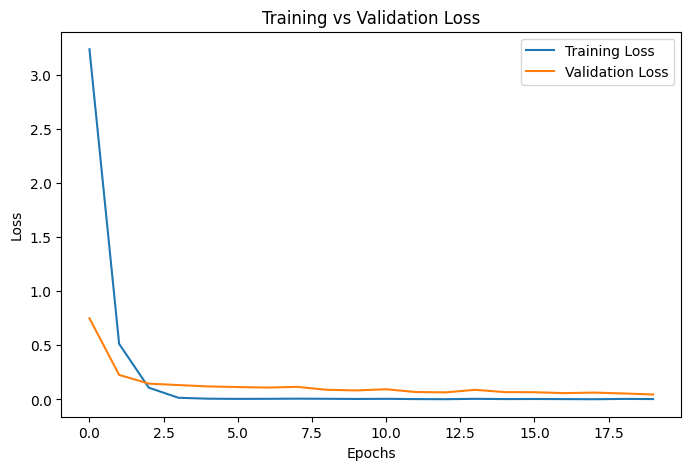

In [26]:
#Plot Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [29]:
#Greedy Decoding Function (Inference)
index_to_word = dict(enumerate(spa_vectorizer.get_vocabulary()))
word_to_index = {v: k for k, v in index_to_word.items()}

#Greedy Translation Function
def greedy_translate(sentence):
    sentence = clean_text(sentence)
    encoder_input = eng_vectorizer([sentence])

    decoder_input = [word_to_index["start"]]

    for _ in range(20):
        decoder_tensor = tf.expand_dims(decoder_input, 0)
        predictions = model((encoder_input, decoder_tensor))
        next_token = tf.argmax(predictions[0, -1]).numpy()

        if index_to_word[next_token] == "end":
            break

        decoder_input.append(next_token)

    translated_words = [index_to_word[idx] for idx in decoder_input[1:]]
    return " ".join(translated_words)


In [30]:
#Show 5 Translation Examples (TEST SET)
for i in range(5):
    eng_sentence = test_en[i]
    true_spa = test_es[i]

    pred_spa = greedy_translate(eng_sentence)

    print(f"English     : {eng_sentence}")
    print(f"Target Spa  : {true_spa}")
    print(f"Prediction  : {pred_spa}")
    print("-" * 50)

English     : tom was a judge in an art contest
Target Spa  : [start] tom fue juez en un concurso de arte [end]
Prediction  : métete métete darles darles darles darles métete métete métete métete métete métete métete métete métete métete métete darles darles darles
--------------------------------------------------
English     : its my umbrella
Target Spa  : [start] es mi paraguas [end]
Prediction  : cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando
--------------------------------------------------
English     : you may choose whichever you want
Target Spa  : [start] tú puedes elegir la que quieras [end]
Prediction  : cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando cuando
--------------------------------------------------
English     : i cant eat the apple
Target Spa  : [start] no puedo comerme la manzana [end]
P

# **Why Self-Attention and Cross-Attention Are Important in Translation**

# Self-attention helps the model understand a sentence by allowing each word to look at other words in the same sentence. In the encoder, this builds meaningful context for the English input. In the decoder, masked self-attention ensures Spanish words are generated one at a time using only previously generated words.

# Cross-attention links the source and target languages. While generating each Spanish word, the decoder uses cross-attention to focus on the most relevant English words. Queries come from the Spanish side, and keys and values come from the English encoder output, enabling proper word alignment and meaning transfer.

# In simple terms, self-attention helps the model understand language structure, while cross-attention helps it translate meaning from English to Spanish. Both are necessary—without self-attention the model lacks context, and without cross-attention it cannot perform translation.